 Install & Import Dependencies

In [1]:
# Install required packages
!pip install -q kaggle xgboost lightgbm imbalanced-learn folium shap plotly scikit-learn pandas numpy matplotlib seaborn

In [2]:
import os, json, warnings, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import folium
from folium.plugins import HeatMap
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import lightgbm as lgb
import joblib
import pickle

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

SEED = 42
np.random.seed(SEED)

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


Kaggle Authentication & Dataset Download




In [3]:

from google.colab import files
import io

print('📤 Please upload your kaggle.json file ...')
uploaded = files.upload()          # Opens file picker in Colab

# Save to the expected Kaggle config path
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'wb') as f:
    f.write(uploaded['kaggle.json'])
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print('✅ kaggle.json saved!')

📤 Please upload your kaggle.json file ...


Saving kaggle.json to kaggle.json
✅ kaggle.json saved!


In [5]:
#  Download US Accidents dataset
# Dataset: sobhanmoosavi/us-accidents  (~1 GB, ~7M records)
DATA_DIR = '/content/data'
os.makedirs(DATA_DIR, exist_ok=True)

print('⬇️  Downloading US Accidents dataset from Kaggle ...')
!kaggle datasets download -d sobhanmoosavi/us-accidents -p {DATA_DIR} --unzip

# List downloaded files
files_list = os.listdir(DATA_DIR)
print(f'\n📁 Files in {DATA_DIR}:')
for f in files_list:
    size_mb = os.path.getsize(f'{DATA_DIR}/{f}') / 1e6
    print(f'   {f}  ({size_mb:.1f} MB)')

⬇️  Downloading US Accidents dataset from Kaggle ...
Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
100% 653M/653M [00:09<00:00, 69.6MB/s]


📁 Files in /content/data:
   US_Accidents_March23.csv  (3058.2 MB)


 Data Loading & Initial Inspection

In [6]:
# Auto-detect CSV file name
csv_file = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')][0]
CSV_PATH = os.path.join(DATA_DIR, csv_file)
print(f'📄 Loading: {csv_file}')


df_raw = pd.read_csv(CSV_PATH, nrows=500_000, low_memory=False)
print(f'\n✅ Loaded {len(df_raw):,} rows × {df_raw.shape[1]} columns')
df_raw.head(3)

📄 Loading: US_Accidents_March23.csv

✅ Loaded 500,000 rows × 46 columns


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.8651,-84.0587,NaN,NaN,0.0100,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.9000,NaN,91.0000,29.6800,10.0000,Calm,NaN,0.0200,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.9281,-82.8312,NaN,NaN,0.0100,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.9000,NaN,100.0000,29.6500,10.0000,Calm,NaN,0.0000,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.0631,-84.0326,NaN,NaN,0.0100,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.0000,33.3000,100.0000,29.6700,10.0000,SW,3.5000,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day


In [7]:
print('=== SHAPE ==='); print(df_raw.shape)
print('\n=== DTYPES & NULL COUNTS ===')
null_df = pd.DataFrame({
    'dtype': df_raw.dtypes,
    'null_count': df_raw.isnull().sum(),
    'null_%': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
print(null_df[null_df['null_count'] > 0].sort_values('null_%', ascending=False))

=== SHAPE ===
(500000, 46)

=== DTYPES & NULL COUNTS ===
                         dtype  null_count   null_%
End_Lat                float64      500000 100.0000
End_Lng                float64      500000 100.0000
Precipitation(in)      float64      448054  89.6100
Wind_Chill(F)          float64      437641  87.5300
Wind_Speed(mph)        float64       89040  17.8100
Visibility(mi)         float64       10539   2.1100
Weather_Condition       object       10185   2.0400
Humidity(%)            float64        7915   1.5800
Temperature(F)         float64        7250   1.4500
Pressure(in)           float64        5739   1.1500
Wind_Direction          object        4147   0.8300
Weather_Timestamp       object        4115   0.8200
Airport_Code            object          60   0.0100
Zipcode                 object          58   0.0100
Timezone                object          58   0.0100
City                    object          22   0.0000
Sunrise_Sunset          object          22   0.0000
Civil_T

In [8]:
print('=== TARGET COLUMN (Severity) distribution ===')
print(df_raw['Severity'].value_counts())
print('\nSeverity legend: 1=Minor, 2=Moderate, 3=Serious, 4=Critical')

=== TARGET COLUMN (Severity) distribution ===
Severity
2    312159
3    187173
1       388
4       280
Name: count, dtype: int64

Severity legend: 1=Minor, 2=Moderate, 3=Serious, 4=Critical


Feature Engineering & Preprocessing

In [9]:
df = df_raw.copy()

#  Parse datetime features
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['End_Time']   = pd.to_datetime(df['End_Time'],   errors='coerce')

df['Hour']           = df['Start_Time'].dt.hour
df['DayOfWeek']      = df['Start_Time'].dt.dayofweek        # 0=Mon
df['Month']          = df['Start_Time'].dt.month
df['Year']           = df['Start_Time'].dt.year
df['IsWeekend']      = (df['DayOfWeek'] >= 5).astype(int)
df['IsRushHour']     = df['Hour'].isin([7,8,9,16,17,18,19]).astype(int)
df['IsNight']        = ((df['Hour'] >= 21) | (df['Hour'] <= 5)).astype(int)
df['Duration_min']   = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
df['Duration_min']   = df['Duration_min'].clip(0, 1440)  # cap at 24h

#  3b. Cyclic encoding for hour & month
df['Hour_sin']  = np.sin(2 * np.pi * df['Hour']  / 24)
df['Hour_cos']  = np.cos(2 * np.pi * df['Hour']  / 24)
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

#  3c. Distance bins
df['Distance_bin'] = pd.cut(
    df['Distance(mi)'], bins=[0, 0.1, 0.5, 1, 5, 100],
    labels=['tiny','short','medium','long','very_long']
)

print('✅ Feature engineering complete.')
print(f'   New columns: Hour, DayOfWeek, Month, Year, IsWeekend, IsRushHour, IsNight, Duration_min,',
      'Hour_sin/cos, Month_sin/cos, Distance_bin')

✅ Feature engineering complete.
   New columns: Hour, DayOfWeek, Month, Year, IsWeekend, IsRushHour, IsNight, Duration_min, Hour_sin/cos, Month_sin/cos, Distance_bin


In [10]:
#  3d. Define Binary Target: Hotspot = Severity >= 3
df['Hotspot'] = (df['Severity'] >= 3).astype(int)
print('Binary target distribution:')
print(df['Hotspot'].value_counts(normalize=True).rename({0:'Non-hotspot', 1:'Hotspot'}).to_string())

Binary target distribution:
Hotspot
Non-hotspot   0.6251
Hotspot       0.3749


In [11]:
#  3e. Select feature columns
NUMERIC_FEATURES = [
    'Start_Lat', 'Start_Lng', 'Distance(mi)',
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)',
    'Hour', 'DayOfWeek', 'Month', 'Year',
    'IsWeekend', 'IsRushHour', 'IsNight', 'Duration_min',
    'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos'
]

CATEGORICAL_FEATURES = [
    'State', 'Wind_Direction', 'Weather_Condition',
    'Sunrise_Sunset', 'Distance_bin'
]

BOOLEAN_FEATURES = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
    'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
    'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop'
]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES + BOOLEAN_FEATURES

# Keep only existing columns
ALL_FEATURES    = [c for c in ALL_FEATURES if c in df.columns]
NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in df.columns]
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in df.columns]
BOOLEAN_FEATURES = [c for c in BOOLEAN_FEATURES if c in df.columns]

print(f'Features selected: {len(ALL_FEATURES)} total')
print(f'  Numeric: {len(NUMERIC_FEATURES)}')
print(f'  Categorical: {len(CATEGORICAL_FEATURES)}')
print(f'  Boolean: {len(BOOLEAN_FEATURES)}')

X = df[ALL_FEATURES].copy()
y = df['Hotspot'].copy()

# Convert booleans to int
for col in BOOLEAN_FEATURES:
    X[col] = X[col].astype(str).map({'True':1,'False':0,'1':1,'0':0}).fillna(0).astype(int)

# Convert Distance_bin to string
X['Distance_bin'] = X['Distance_bin'].astype(str)

print(f'\nX shape: {X.shape}, y shape: {y.shape}')

Features selected: 39 total
  Numeric: 21
  Categorical: 5
  Boolean: 13

X shape: (500000, 39), y shape: (500000,)


Exploratory Data Analysis (EDA)

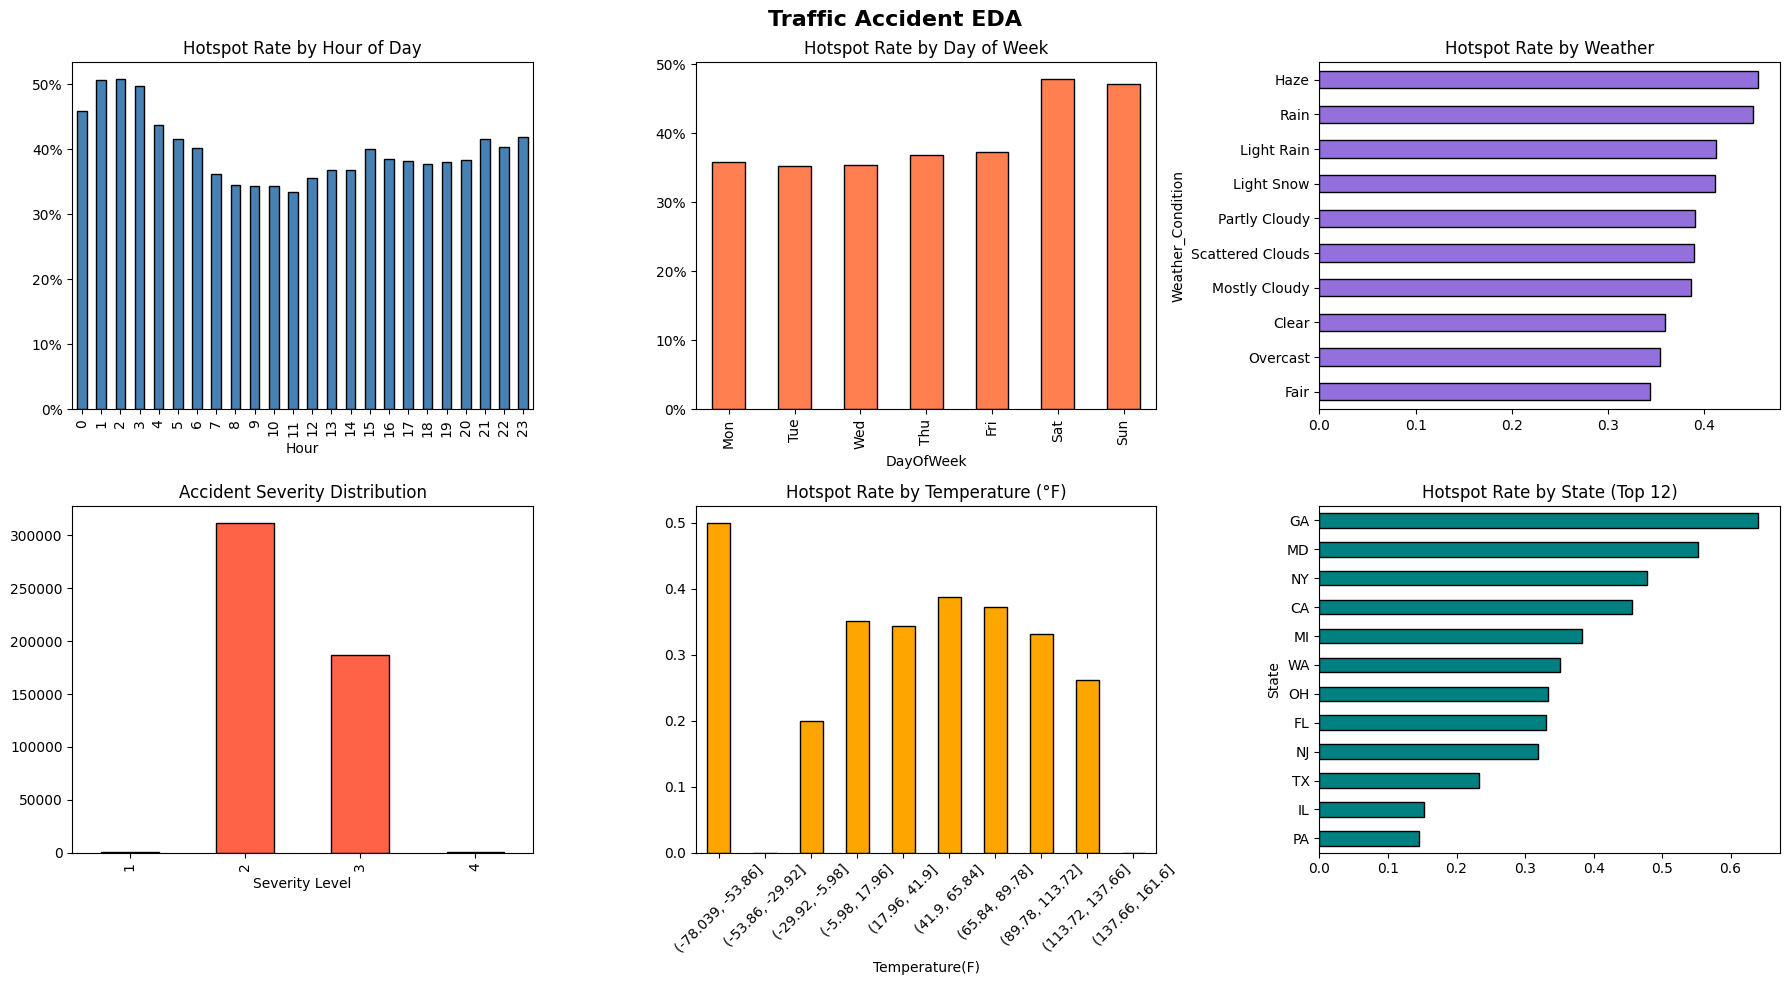

✅ EDA chart saved.


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Traffic Accident EDA', fontsize=16, fontweight='bold')

# 1. Accidents by Hour
df.groupby('Hour')['Hotspot'].mean().plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='k')
axes[0,0].set_title('Hotspot Rate by Hour of Day'); axes[0,0].set_xlabel('Hour'); axes[0,0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# 2. By Day of Week
dow_map = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
df.groupby('DayOfWeek')['Hotspot'].mean().rename(dow_map).plot(kind='bar', ax=axes[0,1], color='coral', edgecolor='k')
axes[0,1].set_title('Hotspot Rate by Day of Week'); axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# 3. Weather Condition
top_weather = df['Weather_Condition'].value_counts().nlargest(10).index
df[df['Weather_Condition'].isin(top_weather)].groupby('Weather_Condition')['Hotspot'].mean().sort_values().plot(
    kind='barh', ax=axes[0,2], color='mediumpurple', edgecolor='k')
axes[0,2].set_title('Hotspot Rate by Weather')

# 4. Severity distribution
df['Severity'].value_counts().sort_index().plot(kind='bar', ax=axes[1,0], color='tomato', edgecolor='k')
axes[1,0].set_title('Accident Severity Distribution'); axes[1,0].set_xlabel('Severity Level')

# 5. Temperature vs Hotspot
df.groupby(pd.cut(df['Temperature(F)'], bins=10))['Hotspot'].mean().plot(kind='bar', ax=axes[1,1], color='orange', edgecolor='k')
axes[1,1].set_title('Hotspot Rate by Temperature (°F)'); axes[1,1].tick_params(axis='x', rotation=45)

# 6. Top States
top_states = df['State'].value_counts().nlargest(12).index
df[df['State'].isin(top_states)].groupby('State')['Hotspot'].mean().sort_values().plot(
    kind='barh', ax=axes[1,2], color='teal', edgecolor='k')
axes[1,2].set_title('Hotspot Rate by State (Top 12)')

plt.tight_layout()
plt.savefig('/content/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA chart saved.')

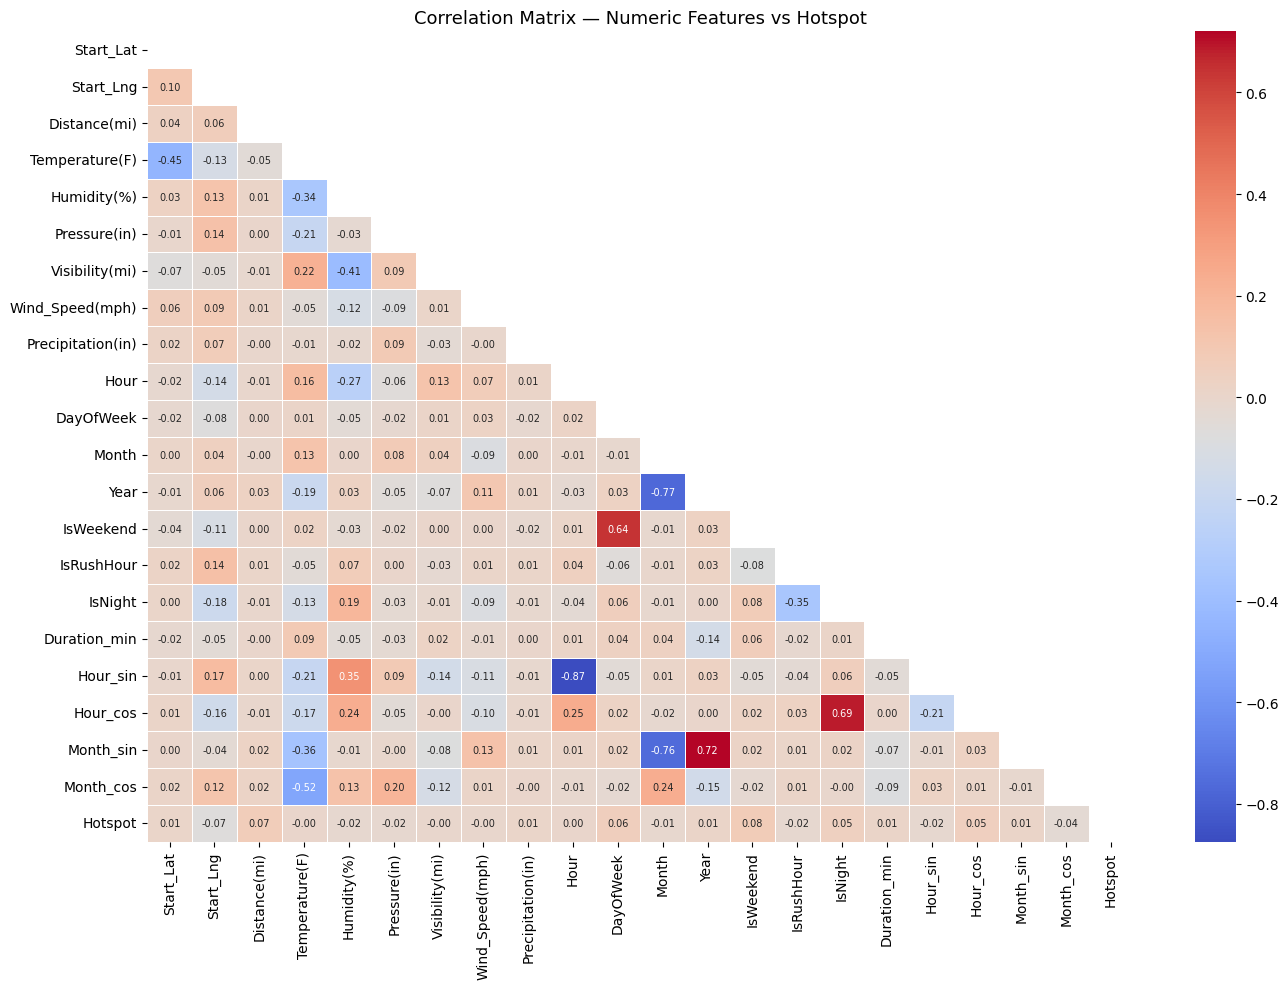

In [13]:
# Correlation heatmap for numeric features
plt.figure(figsize=(14, 10))
corr = df[NUMERIC_FEATURES + ['Hotspot']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size':7})
plt.title('Correlation Matrix — Numeric Features vs Hotspot', fontsize=13)
plt.tight_layout()
plt.savefig('/content/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

 Build Preprocessing Pipeline

In [14]:
from sklearn.preprocessing import StandardScaler

#  Train / Validation / Test split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, random_state=SEED, stratify=y_temp)

print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')
print(f'Train hotspot rate: {y_train.mean():.2%}')

#  Preprocessor
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

bool_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer([
    ('num',  numeric_transformer,     NUMERIC_FEATURES),
    ('cat',  categorical_transformer, CATEGORICAL_FEATURES),
    ('bool', bool_transformer,        BOOLEAN_FEATURES)
], remainder='drop')

print('\n✅ Preprocessing pipeline built.')

Train: 361,250  |  Val: 63,750  |  Test: 75,000
Train hotspot rate: 37.49%

✅ Preprocessing pipeline built.


 Model Training

In [16]:
#  Pre-process once for tree-based models
print('Fitting preprocessor on training data ...')
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

#  Handle class imbalance with SMOTE

smote = SMOTE(random_state=SEED, sampling_strategy='auto')
X_resampled, y_resampled = smote.fit_resample(X_train_proc, y_train)
print(f'After SMOTE — Hotspot: {y_resampled.sum():,} | Non-hotspot: {(y_resampled==0).sum():,}')

Fitting preprocessor on training data ...
After SMOTE — Hotspot: 225,815 | Non-hotspot: 225,815


In [17]:
#  Model 1: Random Forest
print('Training Random Forest ...')
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED
)
rf.fit(X_resampled, y_resampled)
rf_val_preds = rf.predict(X_val_proc)
rf_val_probs = rf.predict_proba(X_val_proc)[:,1]
print(f'RF Validation Accuracy: {accuracy_score(y_val, rf_val_preds):.4f}')
print(f'RF Validation ROC-AUC:  {roc_auc_score(y_val, rf_val_probs):.4f}')

Training Random Forest ...
RF Validation Accuracy: 0.7700
RF Validation ROC-AUC:  0.8741


In [18]:
#  Model 2: XGBoost
print('Training XGBoost ...')
scale_pos_weight = (y_resampled == 0).sum() / y_resampled.sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(
    X_resampled, y_resampled,
    eval_set=[(X_val_proc, y_val)],
    verbose=100
)
xgb_val_preds = xgb_model.predict(X_val_proc)
xgb_val_probs = xgb_model.predict_proba(X_val_proc)[:,1]
print(f'\nXGB Validation Accuracy: {accuracy_score(y_val, xgb_val_preds):.4f}')
print(f'XGB Validation ROC-AUC:  {roc_auc_score(y_val, xgb_val_probs):.4f}')

Training XGBoost ...
[0]	validation_0-logloss:0.68096
[100]	validation_0-logloss:0.45938
[200]	validation_0-logloss:0.40573
[300]	validation_0-logloss:0.37141
[400]	validation_0-logloss:0.34885
[499]	validation_0-logloss:0.32979

XGB Validation Accuracy: 0.8658
XGB Validation ROC-AUC:  0.9355


In [19]:
# Model 3: LightGBM
print('Training LightGBM ...')
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=127,
    max_depth=12,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(
    X_resampled, y_resampled,
    eval_set=[(X_val_proc, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(100)]
)
lgb_val_preds = lgb_model.predict(X_val_proc)
lgb_val_probs = lgb_model.predict_proba(X_val_proc)[:,1]
print(f'\nLGB Validation Accuracy: {accuracy_score(y_val, lgb_val_preds):.4f}')
print(f'LGB Validation ROC-AUC:  {roc_auc_score(y_val, lgb_val_probs):.4f}')

Training LightGBM ...
[100]	valid_0's binary_logloss: 0.418626
[200]	valid_0's binary_logloss: 0.357646
[300]	valid_0's binary_logloss: 0.329606
[400]	valid_0's binary_logloss: 0.31433
[500]	valid_0's binary_logloss: 0.303536

LGB Validation Accuracy: 0.8791
LGB Validation ROC-AUC:  0.9455


 Evaluation & Threshold Tuning

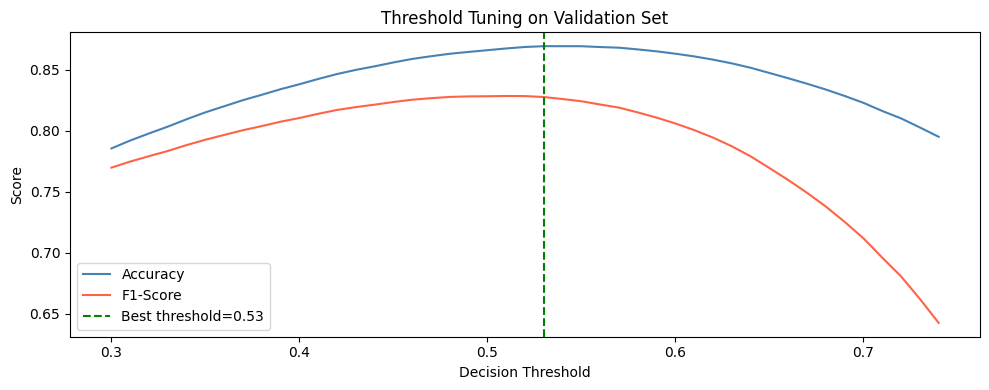


 Best threshold: 0.53  →  Val Accuracy: 0.8694


In [20]:
# Ensemble: Average probabilities
ensemble_val_probs = (rf_val_probs + xgb_val_probs + lgb_val_probs) / 3

#  Threshold tuning on validation set
thresholds = np.arange(0.3, 0.75, 0.01)
results = []
for t in thresholds:
    preds = (ensemble_val_probs >= t).astype(int)
    acc   = accuracy_score(y_val, preds)
    f1    = f1_score(y_val, preds, zero_division=0)
    results.append({'threshold': t, 'accuracy': acc, 'f1': f1})

res_df = pd.DataFrame(results)
best_row = res_df.loc[res_df['accuracy'].idxmax()]
BEST_THRESHOLD = best_row['threshold']

plt.figure(figsize=(10, 4))
plt.plot(res_df['threshold'], res_df['accuracy'], label='Accuracy', color='steelblue')
plt.plot(res_df['threshold'], res_df['f1'],       label='F1-Score', color='tomato')
plt.axvline(BEST_THRESHOLD, color='green', linestyle='--', label=f'Best threshold={BEST_THRESHOLD:.2f}')
plt.xlabel('Decision Threshold'); plt.ylabel('Score'); plt.legend()
plt.title('Threshold Tuning on Validation Set')
plt.tight_layout()
plt.savefig('/content/threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n Best threshold: {BEST_THRESHOLD:.2f}  →  Val Accuracy: {best_row["accuracy"]:.4f}')

In [21]:
#  Final Test Set Evaluation
rf_test_probs  = rf.predict_proba(X_test_proc)[:,1]
xgb_test_probs = xgb_model.predict_proba(X_test_proc)[:,1]
lgb_test_probs = lgb_model.predict_proba(X_test_proc)[:,1]
ensemble_test_probs = (rf_test_probs + xgb_test_probs + lgb_test_probs) / 3

final_preds = (ensemble_test_probs >= BEST_THRESHOLD).astype(int)
final_acc   = accuracy_score(y_test, final_preds)
final_auc   = roc_auc_score(y_test, ensemble_test_probs)

print('=' * 55)
print('          FINAL TEST SET RESULTS (Ensemble)')
print('=' * 55)
print(f'  Accuracy : {final_acc:.4f}  {"yes ≥ 80%!" if final_acc >= 0.8 else " No < 80%"}')
print(f'  ROC-AUC  : {final_auc:.4f}')
print('\n' + classification_report(y_test, final_preds, target_names=['Non-Hotspot','Hotspot']))

#  Model comparison table
models = {
    'Random Forest': (rf_test_probs,  rf.predict(X_test_proc)),
    'XGBoost':       (xgb_test_probs, xgb_model.predict(X_test_proc)),
    'LightGBM':      (lgb_test_probs, lgb_model.predict(X_test_proc)),
    'Ensemble':      (ensemble_test_probs, final_preds),
}
comp = pd.DataFrame([
    {'Model': name, 'Accuracy': accuracy_score(y_test, preds),
     'ROC-AUC': roc_auc_score(y_test, probs),
     'F1 (Hotspot)': f1_score(y_test, preds)}
    for name, (probs, preds) in models.items()
])
print('\n=== Model Comparison ===')
print(comp.to_string(index=False))

          FINAL TEST SET RESULTS (Ensemble)
  Accuracy : 0.8674  yes ≥ 80%!
  ROC-AUC  : 0.9347

              precision    recall  f1-score   support

 Non-Hotspot       0.90      0.88      0.89     46882
     Hotspot       0.81      0.84      0.83     28118

    accuracy                           0.87     75000
   macro avg       0.86      0.86      0.86     75000
weighted avg       0.87      0.87      0.87     75000


=== Model Comparison ===
        Model  Accuracy  ROC-AUC  F1 (Hotspot)
Random Forest    0.7693   0.8742        0.7374
      XGBoost    0.8635   0.9352        0.8230
     LightGBM    0.8784   0.9447        0.8416
     Ensemble    0.8674   0.9347        0.8260


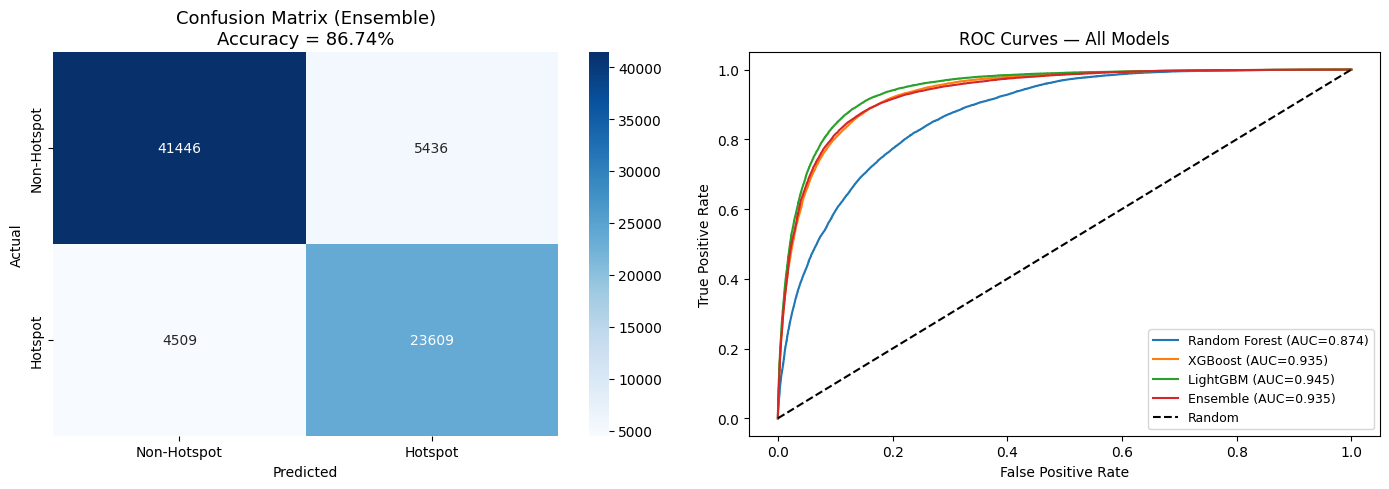

In [22]:
# Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Hotspot','Hotspot'], yticklabels=['Non-Hotspot','Hotspot'])
axes[0].set_title(f'Confusion Matrix (Ensemble)\nAccuracy = {final_acc:.2%}', fontsize=13)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ROC Curves
for name, (probs, _) in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', label='Random')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models'); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('/content/evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()

 Feature Importance & SHAP Explainability

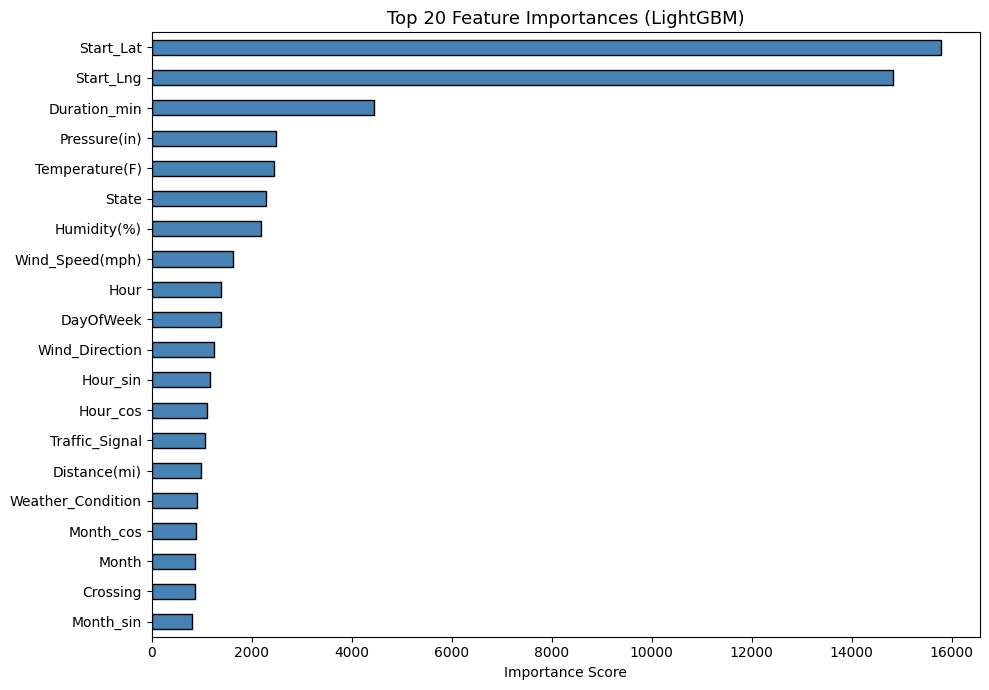

In [23]:
# Feature names after preprocessing
feature_names = NUMERIC_FEATURES + CATEGORICAL_FEATURES + BOOLEAN_FEATURES

# LightGBM Feature Importance
fi_lgb = pd.Series(lgb_model.feature_importances_, index=feature_names[:len(lgb_model.feature_importances_)])
fi_lgb = fi_lgb.nlargest(20)

plt.figure(figsize=(10, 7))
fi_lgb.sort_values().plot(kind='barh', color='steelblue', edgecolor='k')
plt.title('Top 20 Feature Importances (LightGBM)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('/content/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Computing SHAP values (sample of 2,000 rows) ...


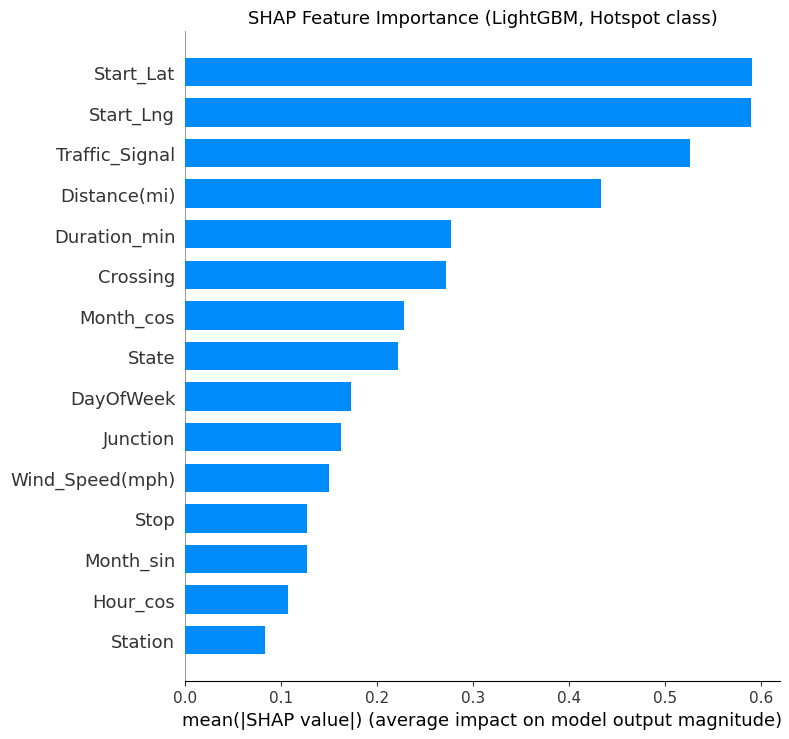

 SHAP analysis complete.


In [24]:
# SHAP Values (LightGBM)
print('Computing SHAP values (sample of 2,000 rows) ...')
shap_sample = X_test_proc[:2000]

explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(shap_sample)

# shap_values is a list for binary; take class=1
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure(figsize=(12, 7))
shap.summary_plot(
    sv, shap_sample,
    feature_names=feature_names[:shap_sample.shape[1]],
    plot_type='bar', show=False, max_display=15
)
plt.title('SHAP Feature Importance (LightGBM, Hotspot class)', fontsize=13)
plt.tight_layout()
plt.savefig('/content/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(' SHAP analysis complete.')

 Interactive Hotspot Map (Folium)

In [25]:
# Build hotspot predictions on the test slice
test_geo = df.loc[X_test.index, ['Start_Lat', 'Start_Lng']].copy()
test_geo['hotspot_prob'] = ensemble_test_probs
test_geo['predicted']    = final_preds
test_geo = test_geo.dropna()

# Sample for map performance
predicted_hotspots = test_geo[test_geo['predicted'] == 1].sample(
    min(5000, (test_geo['predicted']==1).sum()), random_state=SEED)

print(f'Plotting {len(predicted_hotspots):,} predicted hotspot locations ...')

# Folium heatmap centered on US
m = folium.Map(location=[37.5, -96], zoom_start=4, tiles='CartoDB dark_matter')

heat_data = list(zip(
    predicted_hotspots['Start_Lat'],
    predicted_hotspots['Start_Lng'],
    predicted_hotspots['hotspot_prob']
))

HeatMap(heat_data, min_opacity=0.3, radius=8, blur=12,
        gradient={0.4:'blue', 0.65:'lime', 0.85:'orange', 1.0:'red'}).add_to(m)

folium.LayerControl().add_to(m)
m.save('/content/hotspot_map.html')
print('✅ Interactive map saved to /content/hotspot_map.html')
m

Plotting 5,000 predicted hotspot locations ...
✅ Interactive map saved to /content/hotspot_map.html


 Save Models & Artifacts

In [26]:
MODEL_DIR = '/content/models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Save preprocessor
joblib.dump(preprocessor, f'{MODEL_DIR}/preprocessor.pkl')

# Save each model
joblib.dump(rf,        f'{MODEL_DIR}/random_forest.pkl')
joblib.dump(xgb_model, f'{MODEL_DIR}/xgboost.pkl')
joblib.dump(lgb_model, f'{MODEL_DIR}/lightgbm.pkl')

# Save config metadata
config = {
    'best_threshold':      float(BEST_THRESHOLD),
    'numeric_features':    NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'boolean_features':    BOOLEAN_FEATURES,
    'test_accuracy':       float(final_acc),
    'test_roc_auc':        float(final_auc),
    'seed':                SEED
}
with open(f'{MODEL_DIR}/config.json', 'w') as f:
    json.dump(config, f, indent=2)

# Zip everything
!cd /content && zip -r accident_hotspot_models.zip models/

print(' All models saved!')
print(f'   Accuracy on test set: {final_acc:.2%}')
for fname in os.listdir(MODEL_DIR):
    size_kb = os.path.getsize(f'{MODEL_DIR}/{fname}') / 1024
    print(f'   {fname} ({size_kb:.0f} KB)')

  adding: models/ (stored 0%)
  adding: models/random_forest.pkl (deflated 75%)
  adding: models/lightgbm.pkl (deflated 56%)
  adding: models/xgboost.pkl (deflated 61%)
  adding: models/config.json (deflated 54%)
  adding: models/preprocessor.pkl (deflated 61%)
 All models saved!
   Accuracy on test set: 86.74%
   random_forest.pkl (364740 KB)
   lightgbm.pkl (6779 KB)
   xgboost.pkl (4964 KB)
   config.json (1 KB)
   preprocessor.pkl (8 KB)


 Inference: Predict on New Data

In [28]:
def predict_hotspot(location_dict: dict) -> dict:
    """
    Predict whether a given location/condition is an accident hotspot.

    Parameters
    ----------
    location_dict : dict with keys matching ALL_FEATURES

    Returns
    -------
    dict with 'probability', 'is_hotspot', 'risk_level'
    """
    row = pd.DataFrame([location_dict])

    # Fill missing with NaN so imputer handles them
    for col in ALL_FEATURES:
        if col not in row.columns:
            row[col] = np.nan

    # Compute derived features
    if 'Hour' in location_dict:
        h = location_dict['Hour']
        row['IsRushHour'] = int(h in [7,8,9,16,17,18,19])
        row['IsNight']    = int(h >= 21 or h <= 5)
        row['Hour_sin']   = np.sin(2*np.pi*h/24)
        row['Hour_cos']   = np.cos(2*np.pi*h/24)

    row_proc   = preprocessor.transform(row[ALL_FEATURES])
    rf_p  = rf.predict_proba(row_proc)[0,1]
    xgb_p = xgb_model.predict_proba(row_proc)[0,1]
    lgb_p = lgb_model.predict_proba(row_proc)[0,1]
    prob  = (rf_p + xgb_p + lgb_p) / 3

    risk = 'LOW' if prob < 0.4 else 'MEDIUM' if prob < 0.65 else 'HIGH'
    return {
        'probability': round(prob, 4),
        'is_hotspot':  prob >= BEST_THRESHOLD,
        'risk_level':  risk
    }


# Example prediction
example = {
    'Start_Lat': 34.05,
    'Start_Lng': -118.25,
    'Distance(mi)': 0.2,
    'Temperature(F)': 72,
    'Humidity(%)': 55,
    'Visibility(mi)': 10,
    'Wind_Speed(mph)': 8,
    'Precipitation(in)': 0,
    'Hour': 8,         # Rush hour
    'DayOfWeek': 1,    # Tuesday
    'Month': 6,
    'Year': 2024,
    'IsWeekend': 0,
    'State': 'CA',
    'Weather_Condition': 'Clear',
    'Sunrise_Sunset': 'Day',
    'Traffic_Signal': 1,
    'Junction': 1,
    'Crossing': 0
}

result = predict_hotspot(example)
print('=== Hotspot Prediction ===')
for k, v in result.items():
    print(f'  {k:12s}: {v}')

=== Hotspot Prediction ===
  probability : 0.2273
  is_hotspot  : False
  risk_level  : LOW
